# Bölüm 2 — İlaç Sektörü Satış ve Talep Analizi

Dört pazar (A, B, C, D) × 124 ay (2016-01 → 2026-04) satış verisi üzerinde case'in
yedi analiz sorusu. Hesaplar `src/analysis/` altındaki test edilmiş modüllerde;
bu notebook onları çağırır, grafikler ve yorumlar.

Her görevin altında iki ayrı yorum var: **Teknik yorum** (yöntem, sınırlılık,
istatistiksel güven) ve **İş yorumu** (ne yapılmalı).

> ⚠️ **Önce okunması gereken:** `MF Oran` kolonu B Pazarı'nda yüzde (0–100),
> diğer pazarlarda oran (0–1) ölçeğinde. Düzeltilmezse `Net Kutu = Brüt × (1 − MF)`
> negatife düşüyor ve birim fiyat 8,32 TL yerine **−0,88 TL** çıkıyor. A4, A6 ve A7
> bu düzeltme olmadan tamamen yanlış olurdu. Düzeltme sabit "B Pazarı" kuralıyla
> değil, **grup medyanına bakan program tespitiyle** yapılıyor.

In [1]:
# Depo kökünü yola ekle — notebook `notebooks/` içinden koşuyor.
# Ayrı hücrede, çünkü proje modülleri ancak bu satırdan sonra import edilebilir.
import sys
from pathlib import Path

KOK = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(KOK) not in sys.path:
    sys.path.insert(0, str(KOK))

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.analysis.clean import temizle
from src.analysis.load import yukle_ham
from src.analysis.metrics import (
    hhi,
    mevsimsel_indeks,
    mevsimsellik_gucu,
    pazar_payi,
    turetilmis_metrikler,
)
from src.analysis.plots import PAZAR_RENKLERI, SIRKET_RENKLERI, kaydet, stil_uygula, tr_sayi

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

stil_uygula()
PAZARLAR = ["A Pazarı", "B Pazarı", "C Pazarı", "D Pazarı"]

---
## 1. Veri kalitesi raporu

Analizden önce yedi ölçülmüş veri sorunu düzeltiliyor. Hiçbir kayıt sessizce
silinmiyor — her düzeltme sayılıyor ve aşağıda raporlanıyor.

In [3]:
ham = yukle_ham()
temiz, rapor = temizle(ham)
df = turetilmis_metrikler(temiz)

olcek_metni = ", ".join(f"{p} (÷{int(f)})" for p, f in rapor.olcek_duzeltilen_pazarlar.items())
kalite = pd.DataFrame(
    [
        ("Ham gözlem", tr_sayi(rapor.ham_gozlem)),
        ("Temiz gözlem", tr_sayi(rapor.temiz_gozlem)),
        ("MF ölçeği düzeltilen pazar", olcek_metni),
        ("MF kırpılan gözlem [0; 0,95]", tr_sayi(rapor.mf_kirpilan)),
        ("İade (negatif) gözlem", tr_sayi(rapor.iade_gozlem)),
        ("İlk satış öncesi atılan gözlem", tr_sayi(rapor.ilk_satis_oncesi_atilan)),
        ("Kısa seri (24 aydan az satış)", tr_sayi(len(rapor.kisa_seriler))),
    ],
    columns=["Kontrol", "Değer"],
)
kalite

,Kontrol,Değer
0,Ham gözlem,46.376
1,Temiz gözlem,40.469
2,MF ölçeği düzeltilen pazar,B Pazarı (÷100)
3,"MF kırpılan gözlem [0; 0,95]",1.548
4,İade (negatif) gözlem,1.185
5,İlk satış öncesi atılan gözlem,5.907
6,Kısa seri (24 aydan az satış),57


In [4]:
# MF ölçek düzeltmesinin somut etkisi — case'in birim fiyat tanımıyla doğrulama.
ornek = temiz[
    (temiz.pazar == "B Pazarı")
    & (temiz.sirket == "Şirket 1")
    & (temiz.urun == "Ürün-FR")
    & (temiz.tarih.isin(pd.to_datetime(["2016-01-01", "2016-03-01", "2026-03-01"])))
].copy()
ornek["fiyat_duzeltmesiz"] = ornek.net_tl / (ornek.brut_kutu * (1 - ornek.mf_oran))
ornek["fiyat_duzeltmeli"] = ornek.net_tl / (ornek.brut_kutu * (1 - ornek.mf_oran_temiz))
gosterilecek = ["tarih", "brut_kutu", "mf_oran", "mf_oran_temiz"]
ornek[gosterilecek + ["fiyat_duzeltmesiz", "fiyat_duzeltmeli"]].round(2)

,tarih,brut_kutu,mf_oran,mf_oran_temiz,fiyat_duzeltmesiz,fiyat_duzeltmeli
27209,2016-01-01,27378.0,9.54,0.10,-0.88,8.32
27211,2016-03-01,56533.0,10.13,0.10,-0.79,8.07
27331,2026-03-01,38257.0,6.51,0.07,-24.08,141.84


**Düzeltmenin kanıtı yukarıdaki tabloda:** ham `MF Oran` değeri 9,54 — bir oran olarak
okunursa Net Kutu negatife düşüyor ve birim fiyat **eksi** çıkıyor. 100'e bölündüğünde
2016'da ~8,3 TL, 2026'da ~142 TL oluyor; bu, A Pazarı/Ürün-A'nın 10,3 → 157 TL bandıyla
aynı büyüklük mertebesi ve on yıllık TL enflasyonuyla tutarlı.

Kısa seriler analizden **çıkarılmıyor**, ayrıca raporlanıyor — bunlar için mevsimsellik
ve tahmin matematiksel olarak mümkün değil.

In [5]:
kisa_s1 = {k: v for k, v in rapor.kisa_seriler.items() if k[1] == "Şirket 1"}
pd.DataFrame(
    [(p, u, f"{n} ay satış") for (p, s, u), n in sorted(kisa_s1.items())],
    columns=["Pazar", "Ürün", "Geçmiş"],
)

,Pazar,Ürün,Geçmiş
0,C Pazarı,Ürün 1,1 ay satış
1,D Pazarı,Ürün 78,11 ay satış


---
## A1 — Son 2 yılın satış performansı ve ürün kırılımı

Verinin son ayı 2026-04 olduğu için "son 2 yıl" = **2024-05 … 2026-04**.

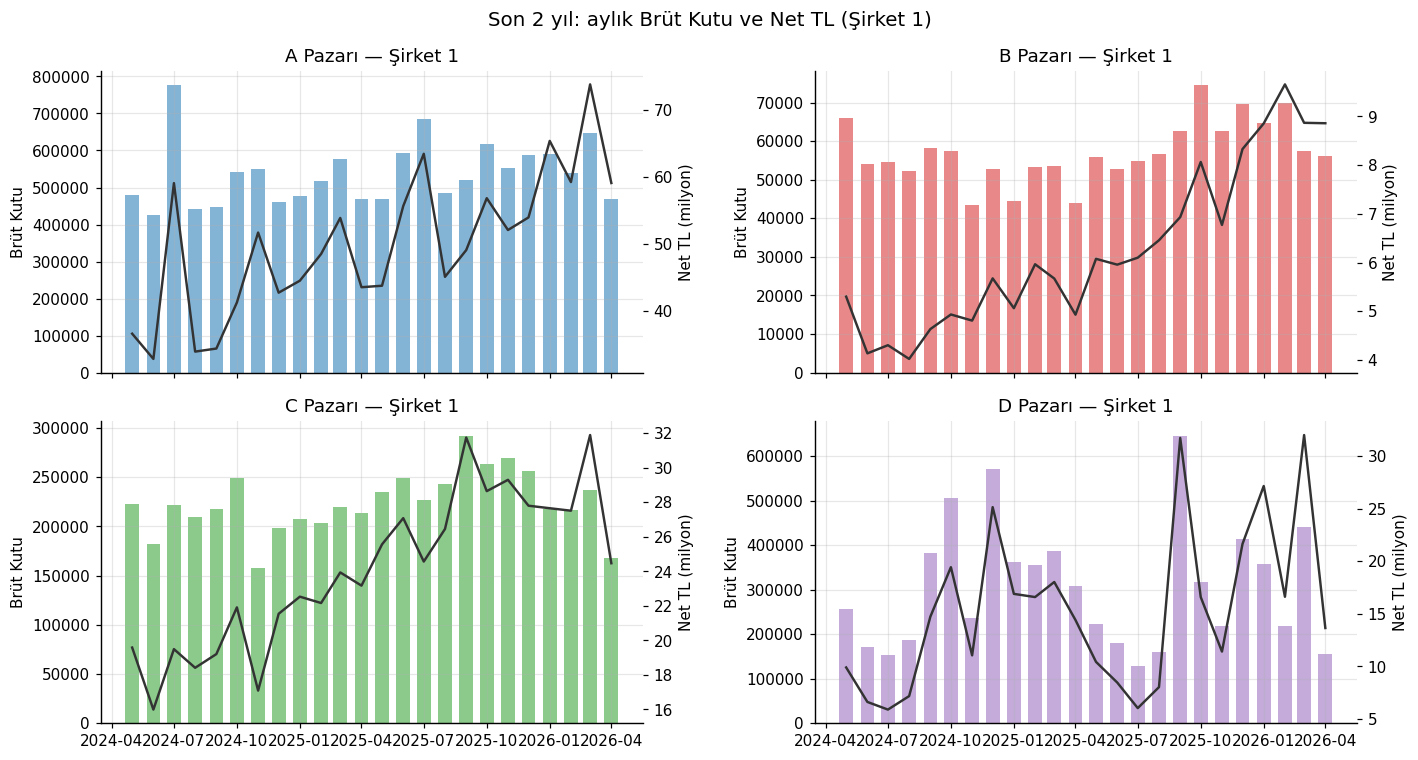

In [6]:
SON_2_YIL = pd.Timestamp("2024-05-01")
s1 = df[df.sirket == "Şirket 1"]
son2 = s1[s1.tarih >= SON_2_YIL]

fig, eksenler = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for eksen, pazar in zip(eksenler.ravel(), PAZARLAR, strict=True):
    g = (
        son2[son2.pazar == pazar]
        .groupby("tarih", observed=True)
        .agg(brut=("brut_kutu", "sum"), net=("net_tl", "sum"))
    )
    eksen.bar(g.index, g.brut, width=20, color=PAZAR_RENKLERI[pazar], alpha=0.55, label="Brüt Kutu")
    ikinci = eksen.twinx()
    ikinci.plot(g.index, g.net / 1e6, color="#333333", linewidth=1.6, label="Net TL (milyon)")
    ikinci.grid(False)
    eksen.set_title(f"{pazar} — Şirket 1")
    eksen.set_ylabel("Brüt Kutu")
    ikinci.set_ylabel("Net TL (milyon)")
fig.suptitle("Son 2 yıl: aylık Brüt Kutu ve Net TL (Şirket 1)", fontsize=13)
fig.tight_layout()
kaydet(fig, "a1_pazar_bazinda_satis")
plt.show()

In [7]:
ozet = son2.groupby("pazar", observed=True).agg(
    brut_kutu=("brut_kutu", "sum"), net_tl=("net_tl", "sum")
)
ort_mf = son2.groupby("pazar", observed=True).mf_oran_temiz.mean()
ozet["birim_fiyat_ort"] = ozet.net_tl / (ozet.brut_kutu * (1 - ort_mf))
ozet.style.format({"brut_kutu": "{:,.0f}", "net_tl": "{:,.0f}", "birim_fiyat_ort": "{:,.2f}"})

,brut_kutu,net_tl,birim_fiyat_ort
pazar,,,
A Pazarı,"12,918,121","1,200,778,640",94.85
B Pazarı,"1,372,128","150,396,579",117.88
C Pazarı,"5,378,746","577,851,376",107.47
D Pazarı,"7,335,930","369,676,206",50.81


In [8]:
# Ürün dominasyonu: her pazarda en büyük ürün hacmin yüzde kaçını taşıyor?
satirlar = []
for pazar in PAZARLAR:
    t = son2[son2.pazar == pazar].groupby("urun", observed=True).brut_kutu.sum()
    t = t.sort_values(ascending=False)
    t = t[t > 0]
    satirlar.append(
        {
            "Pazar": pazar,
            "Ürün sayısı": len(t),
            "En büyük ürün": t.index[0],
            "Payı (%)": round(100 * t.iloc[0] / t.sum(), 1),
            "İlk 2 ürün payı (%)": round(100 * t.iloc[:2].sum() / t.sum(), 1),
        }
    )
dominasyon = pd.DataFrame(satirlar)
dominasyon

,Pazar,Ürün sayısı,En büyük ürün,Payı (%),İlk 2 ürün payı (%)
0,A Pazarı,10,Ürün-G,29.1,48.4
1,B Pazarı,4,Ürün-FR,69.5,97.3
2,C Pazarı,1,Ürün 2,100.0,100.0
3,D Pazarı,2,Ürün 77,60.6,100.0


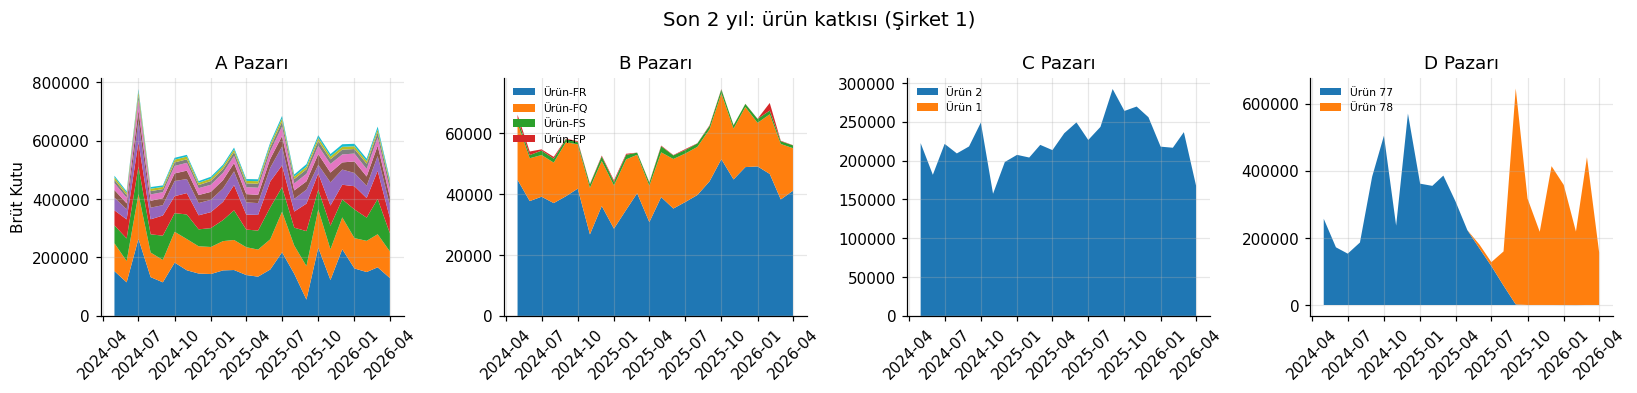

In [9]:
fig, eksenler = plt.subplots(1, 4, figsize=(15, 3.6), sharey=False)
for eksen, pazar in zip(eksenler, PAZARLAR, strict=True):
    g = (
        son2[son2.pazar == pazar]
        .pivot_table(
            index="tarih", columns="urun", values="brut_kutu", aggfunc="sum", observed=True
        )
        .fillna(0.0)
    )
    g = g.loc[:, g.sum().sort_values(ascending=False).index]
    eksen.stackplot(g.index, g.T.to_numpy(), labels=list(g.columns))
    eksen.set_title(pazar)
    eksen.tick_params(axis="x", rotation=45)
    if g.shape[1] <= 4:
        eksen.legend(fontsize=7, loc="upper left")
eksenler[0].set_ylabel("Brüt Kutu")
fig.suptitle("Son 2 yıl: ürün katkısı (Şirket 1)", fontsize=13)
fig.tight_layout()
kaydet(fig, "a1_urun_katkisi")
plt.show()

In [10]:
# Zirve ve dip aylar: ay ortalamasının pazar ortalamasına oranı.
aylik = son2.groupby(["pazar", son2.tarih.dt.month], observed=True).brut_kutu.mean().rename("ort")
aylik = aylik.reset_index().rename(columns={"tarih": "ay"})
aylik["endeks"] = aylik.groupby("pazar", observed=True).ort.transform(lambda s: 100 * s / s.mean())
zirve_dip = pd.DataFrame(
    [
        {
            "Pazar": pazar,
            "Zirve ay": int(g.loc[g.endeks.idxmax(), "ay"]),
            "Zirve endeks": round(g.endeks.max(), 1),
            "Dip ay": int(g.loc[g.endeks.idxmin(), "ay"]),
            "Dip endeks": round(g.endeks.min(), 1),
        }
        for pazar, g in aylik.groupby("pazar", observed=True)
    ]
)
zirve_dip

,Pazar,Zirve ay,Zirve endeks,Dip ay,Dip endeks
0,A Pazarı,7,135.7,8,85.9
1,B Pazarı,10,115.4,4,87.5
2,C Pazarı,10,111.8,2,91.7
3,D Pazarı,9,162.9,7,44.5


#### Teknik yorum

Dört pazar hacim olarak üç mertebe farklı değil ama **büyüklük sıralaması ciroyla
uyuşmuyor**: D Pazarı kutu bazında ikinci sırada, Net TL bazında sonuncuya yakın —
yani D'de birim fiyat belirgin şekilde düşük. Bu, A6'daki fiyat analizinin
habercisidir ve ciro ile hacmi ayrı okumak gerektiğini gösterir.

Ürün kırılımında C Pazarı bir uç durum: iki üründen biri (`Ürün 1`) son iki yılda
tek bir kutu bile satmamış, dolayısıyla hacmin **%100'ü** tek üründe. B Pazarı'nda da
tek ürün (`Ürün-FR`) hacmin ~%70'ini taşıyor. A Pazarı on ürünle en dengeli dağılıma
sahip; en büyük ürünün payı %30'un altında.

Zirve/dip endeksleri burada yalnız iki yılın ortalaması — mevsimsellik iddiası için
zayıf bir temel. Asıl mevsimsellik ölçümü A3'te STL ile, 124 ayın tamamı üzerinden
yapılıyor.

#### İş yorumu

C ve B pazarlarındaki tek ürün yoğunlaşması **konsantrasyon riski**: o üründe bir
tedarik kesintisi ya da fiyat baskısı, pazarın tamamını götürür. A Pazarı'nın dengeli
portföyü bu açıdan sağlıklı. D Pazarı'nda hacim yüksek ama ciro düşük — buradaki
işin kârlılığı ayrıca sorgulanmalı (A6'daki birim fiyat ve promosyon maliyeti
tablosuyla birlikte okunmalı).

---
## A2 — Pazar payları ve rekabet pozisyonu

Paylar `Brüt Kutu` üzerinden, pazar-ay bazında hesaplanıyor. Üç oyuncu: Şirket 1
(ana firma), Şirket 2 (doğrudan rakip), Diğer Şirket (pazardaki diğer tüm firmalar).

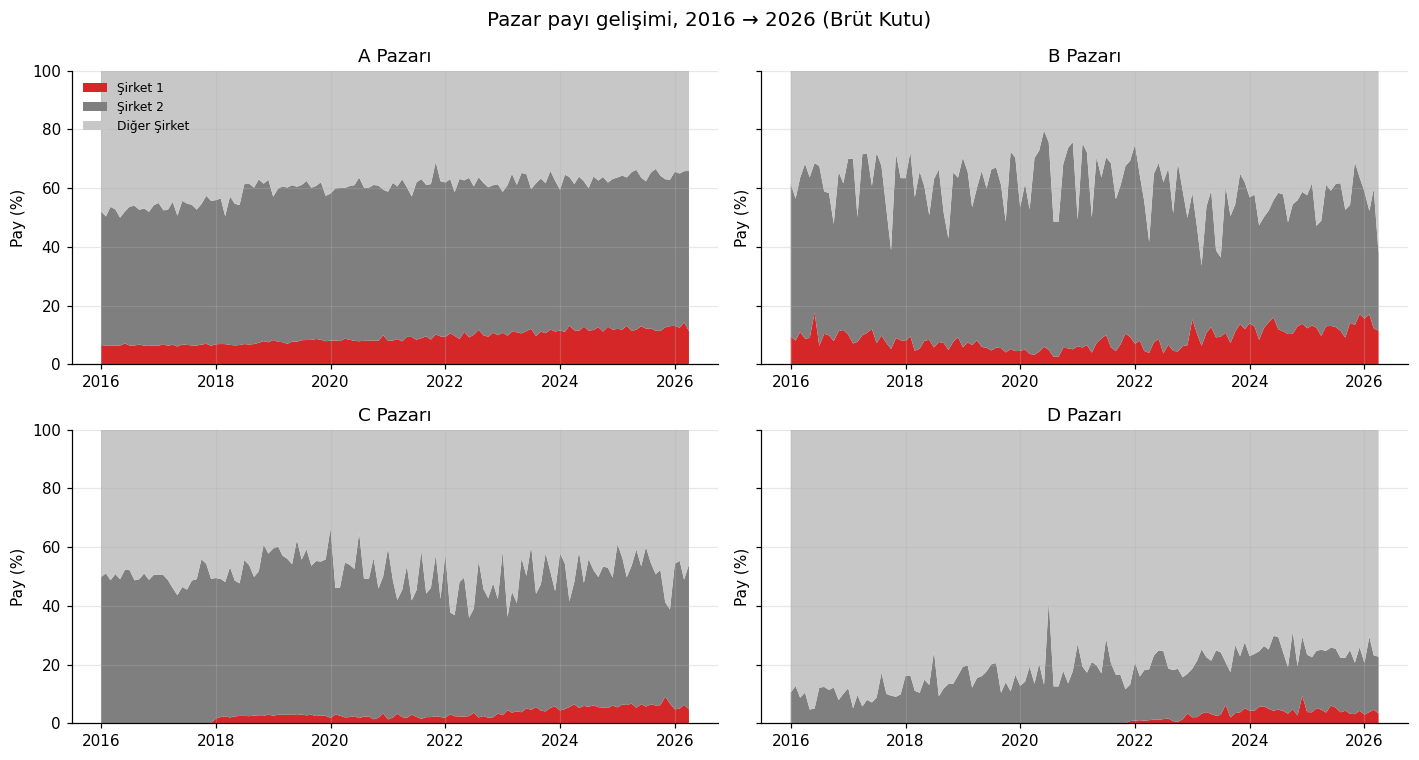

In [11]:
paylar = pazar_payi(df)

fig, eksenler = plt.subplots(2, 2, figsize=(13, 7), sharey=True)
for eksen, pazar in zip(eksenler.ravel(), PAZARLAR, strict=True):
    g = paylar[paylar.pazar == pazar].pivot_table(
        index="tarih", columns="sirket", values="pay", observed=True
    )
    sira = [s for s in ["Şirket 1", "Şirket 2", "Diğer Şirket"] if s in g.columns]
    g = g[sira].fillna(0.0)
    eksen.stackplot(g.index, g.T.to_numpy(), labels=sira, colors=[SIRKET_RENKLERI[s] for s in sira])
    eksen.set_title(pazar)
    eksen.set_ylim(0, 100)
    eksen.set_ylabel("Pay (%)")
eksenler[0, 0].legend(loc="upper left", fontsize=8)
fig.suptitle("Pazar payı gelişimi, 2016 → 2026 (Brüt Kutu)", fontsize=13)
fig.tight_layout()
kaydet(fig, "a2_pazar_paylari")
plt.show()

In [12]:
# 2016 ve son 12 ay payları yan yana — değişimin yönü.
ilk_yil = (
    paylar[paylar.tarih.dt.year == 2016].groupby(["pazar", "sirket"], observed=True).pay.mean()
)
son_yil = (
    paylar[paylar.tarih >= paylar.tarih.max() - pd.DateOffset(months=11)]
    .groupby(["pazar", "sirket"], observed=True)
    .pay.mean()
)
karsilastirma = pd.concat([ilk_yil.rename("2016 (%)"), son_yil.rename("Son 12 ay (%)")], axis=1)
karsilastirma["Değişim (puan)"] = karsilastirma["Son 12 ay (%)"] - karsilastirma["2016 (%)"]
karsilastirma.round(1)

2016 (%)  Son 12 ay (%)  Değişim (puan)
pazar    sirket                                               
A Pazarı Diğer Şirket      47.5           35.3           -12.2
         Şirket 1           6.5           12.4             5.9
         Şirket 2          46.0           52.3             6.3
B Pazarı Diğer Şirket      38.2           42.4             4.2
         Şirket 1          10.1           13.3             3.2
         Şirket 2          51.7           44.3            -7.4
C Pazarı Diğer Şirket      49.8           48.1            -1.7
         Şirket 2          50.2           45.9            -4.3
D Pazarı Diğer Şirket      90.2           76.0           -14.2
         Şirket 2           9.8           19.9            10.1
C Pazarı Şirket 1           NaN            6.1             NaN
D Pazarı Şirket 1           NaN            4.0             NaN

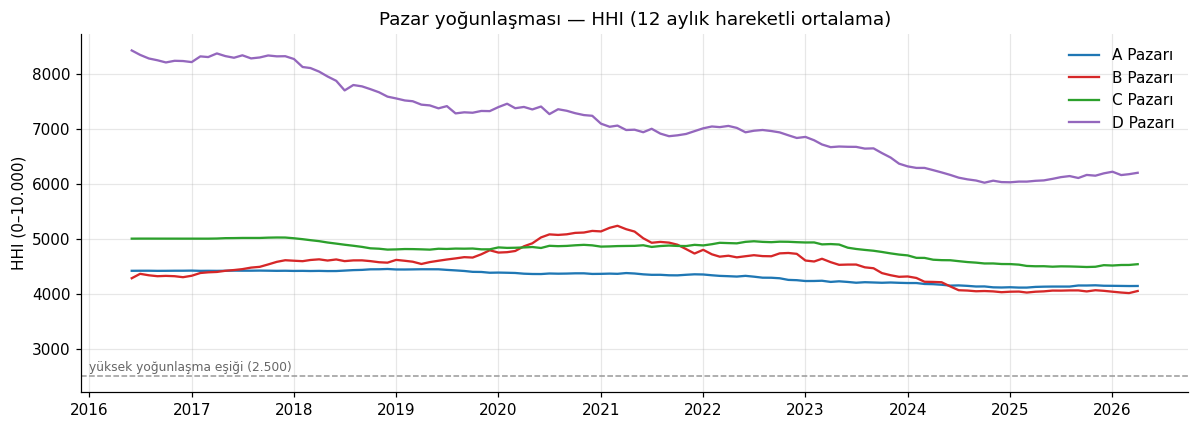

In [13]:
# HHI: pazar yoğunlaşması artıyor mu?
h = hhi(df)
fig, eksen = plt.subplots(figsize=(11, 4))
for pazar in PAZARLAR:
    g = h[h.pazar == pazar].set_index("tarih").hhi.rolling(12, min_periods=6).mean()
    eksen.plot(g.index, g, label=pazar, color=PAZAR_RENKLERI[pazar])
eksen.axhline(2500, color="#999999", linestyle="--", linewidth=1)
eksen.text(h.tarih.min(), 2600, "yüksek yoğunlaşma eşiği (2.500)", fontsize=8, color="#666666")
eksen.set_title("Pazar yoğunlaşması — HHI (12 aylık hareketli ortalama)")
eksen.set_ylabel("HHI (0–10.000)")
eksen.legend()
fig.tight_layout()
kaydet(fig, "a2_hhi")
plt.show()

In [14]:
# "Orantısız pay": pazar toplamı ne kadar büyüdü, Şirket 1 ne kadar?
# 2026 kısmi bir yıl (yalnız 4 ay) olduğu için hesap 2016–2025 tam yılları üzerinden.
# Her pazarda Şirket 1'in **kendi** varlık aralığı kullanılır: D Pazarı'nda ürünler
# 2021 ve 2025'te başlıyor, 2016'dan CAGR hesaplamak anlamsız olurdu.
def _cagr(ilk_deger: float, son_deger: float, yil_farki: int) -> float:
    if yil_farki <= 0 or ilk_deger <= 0 or son_deger <= 0:
        return float("nan")
    return 100 * ((son_deger / ilk_deger) ** (1 / yil_farki) - 1)


satirlar = []
for pazar in PAZARLAR:
    g = df[df.pazar == pazar]
    yp = g.groupby(g.tarih.dt.year, observed=True).brut_kutu.sum()
    ys = g[g.sirket == "Şirket 1"].groupby(g.tarih.dt.year, observed=True).brut_kutu.sum()
    ortak = [y for y in range(2016, 2026) if yp.get(y, 0) > 0 and ys.get(y, 0) > 0]
    if len(ortak) < 2:
        satirlar.append({"Pazar": pazar, "Aralık": "yetersiz veri"})
        continue
    ilk, son = ortak[0], ortak[-1]
    pazar_cagr = _cagr(yp[ilk], yp[son], son - ilk)
    s1_cagr = _cagr(ys[ilk], ys[son], son - ilk)
    satirlar.append(
        {
            "Pazar": pazar,
            "Aralık": f"{ilk}–{son}",
            "Pazar CAGR (%)": round(pazar_cagr, 1),
            "Şirket 1 CAGR (%)": round(s1_cagr, 1),
            "Fark (puan)": round(s1_cagr - pazar_cagr, 1),
        }
    )
cagr_tablosu = pd.DataFrame(satirlar)
cagr_tablosu

,Pazar,Aralık,Pazar CAGR (%),Şirket 1 CAGR (%),Fark (puan)
0,A Pazarı,2016–2025,2.8,10.2,7.4
1,B Pazarı,2016–2025,0.8,3.2,2.4
2,C Pazarı,2017–2025,4.3,131.8,127.5
3,D Pazarı,2021–2025,14.1,186.5,172.4


#### Teknik yorum

Şirket 1'in payı dört pazarda da **%15'in altında**: A'da ~%12, B'de ~%13, C'de ~%6,
D'de ~%4. Yani Şirket 1 hiçbir pazarda lider değil; A ve B'de Şirket 2 açık ara önde,
C ve D'de pazarın büyük kısmı "Diğer Şirket" çatısı altındaki dağınık rekabette.

HHI dört pazarda da düşüş eğiliminde — yani **yoğunlaşma azalıyor, rekabet artıyor**.
D Pazarı 2016'da 8.240 ile neredeyse tekelci bir yapıdayken bugün 6.226'ya inmiş; en
büyük yapısal değişim orada. Yine de dört pazar da 2.500 eşiğinin çok üzerinde,
yani hepsi "yüksek yoğunlaşmalı" sayılır.

"Orantısız pay" sorusunun cevabı **evet, dört pazarda da**: Şirket 1 her pazarda
pazarın kendisinden hızlı büyümüş (A'da 10,2 vs 2,8; B'de 3,2 vs 0,8). Ama bu tablo
dikkatli okunmalı.

⚠️ **İki uyarı.** (1) 2026 kısmi bir yıl (yalnız 4 ay) olduğu için hesap 2016–2025
tam yılları üzerinden; aksi hâlde son yıl yapay olarak düşük çıkardı. (2) C Pazarı'nda
%131,8 ve D Pazarı'nda %186,5'lik CAGR **sıfıra yakın bir tabandan** geliyor:
Şirket 1 C'ye 2017'de, D'ye 2021'de girmiş ve ilk yıl hacmi çok küçük. Böyle bir
tabanda CAGR matematiksel olarak doğru ama iş anlamında yanıltıcıdır — bu yüzden
her satırda hesabın hangi aralıkta yapıldığı ayrıca yazılıyor. Pay tablosu (yukarıda)
bu büyümenin Şirket 1'i hâlâ %6 ve %4 seviyesinde bıraktığını gösteriyor.

#### İş yorumu

Şirket 1 için en gerçekçi büyüme alanı **B Pazarı**: payı görece yüksek (~%13) ve
pazar Şirket 2 ile paylaşılıyor, yani rekabet iki oyuncu arasında — pay almak için
dağınık bir kalabalıkla değil tek rakiple mücadele etmek gerekiyor. D Pazarı'nda ise
%4'lük pay ve düşük birim fiyat birlikte okunduğunda, yatırım yapılacak yer olup
olmadığı ciddi biçimde sorgulanmalı.

İyi haber: Şirket 1 dört pazarda da pazardan hızlı büyüyor, yani pay **kazanıyor**.
Kötü haber: başladığı taban o kadar düşük ki A ve B'de bile on yılda liderliğe yakın
bir yere gelememiş. C ve D'deki üç haneli büyüme oranlarını hedef olarak sunmak
yanıltıcı olur — oradaki asıl soru büyüme hızı değil, mutlak hacmin anlamlı bir
seviyeye çıkıp çıkmayacağı.

---
## A3 — Mevsimsellik

Mevsimsel indeks ve mevsimsellik gücü **STL ayrıştırmasıyla** (`robust=True`)
hesaplanıyor. Veride promosyon kaynaklı sıçramalar var; klasik ayrıştırma onlara
aşırı tepki verip mevsimselliği çarpıtıyor.

⚠️ **24 aydan az satış görmüş serilerde hesap yapılmıyor.** 12 aylık döngünün en az
iki tekrarı gerekiyor. Bu eşik satır sayısına değil **satış görülen ay** sayısına
bakıyor: `C Pazarı/Ürün 1` kırpma sonrası 28 satır taşıyor ama yalnız bir ayında
satışı var — satır sayısına bakan bir eşik bunu kabul ediyor ve STL o tek sıçramayı
"mevsimsellik gücü 0,99" diye raporluyordu. Uydurulmuş mevsimsellik, "hesaplanamadı"
demekten daha kötüdür.

In [15]:
satirlar = []
for (pazar, urun), g in s1.groupby(["pazar", "urun"], observed=True):
    seri = g.sort_values("tarih").set_index("tarih").brut_kutu.astype(float)
    guc = mevsimsellik_gucu(seri)
    indeks = mevsimsel_indeks(seri)
    satisli = int((seri > 0).sum())
    satirlar.append(
        {
            "Pazar": pazar,
            "Ürün": urun,
            "Satışlı ay": satisli,
            "Mevsimsellik gücü": None if guc is None else round(guc, 3),
            "Zirve ay": None if indeks is None else int(indeks.idxmax()),
            "Zirve endeksi": None if indeks is None else round(float(indeks.max()), 2),
            "Not": (
                "yetersiz veri"
                if guc is None
                else ("sınırda — 3 döngüden az" if satisli < 36 else "")
            ),
        }
    )
mevsimsellik = pd.DataFrame(satirlar)
mevsimsellik

,Pazar,Ürün,Satışlı ay,Mevsimsellik gücü,Zirve ay,Zirve endeksi,Not
0,A Pazarı,Ürün-A,124,0.481,9.0,1.19,
1,A Pazarı,Ürün-B,124,0.368,3.0,1.17,
2,A Pazarı,Ürün-C,124,0.289,7.0,1.14,
3,A Pazarı,Ürün-D,124,0.160,7.0,1.12,
4,A Pazarı,Ürün-E,124,0.235,7.0,1.14,
5,A Pazarı,Ürün-F,124,0.136,9.0,1.27,
6,A Pazarı,Ürün-G,124,0.324,7.0,1.20,
7,A Pazarı,Ürün-H,124,0.286,7.0,1.21,
8,A Pazarı,Ürün-I,124,0.304,7.0,1.22,
9,A Pazarı,Ürün-J,124,0.304,7.0,1.19,


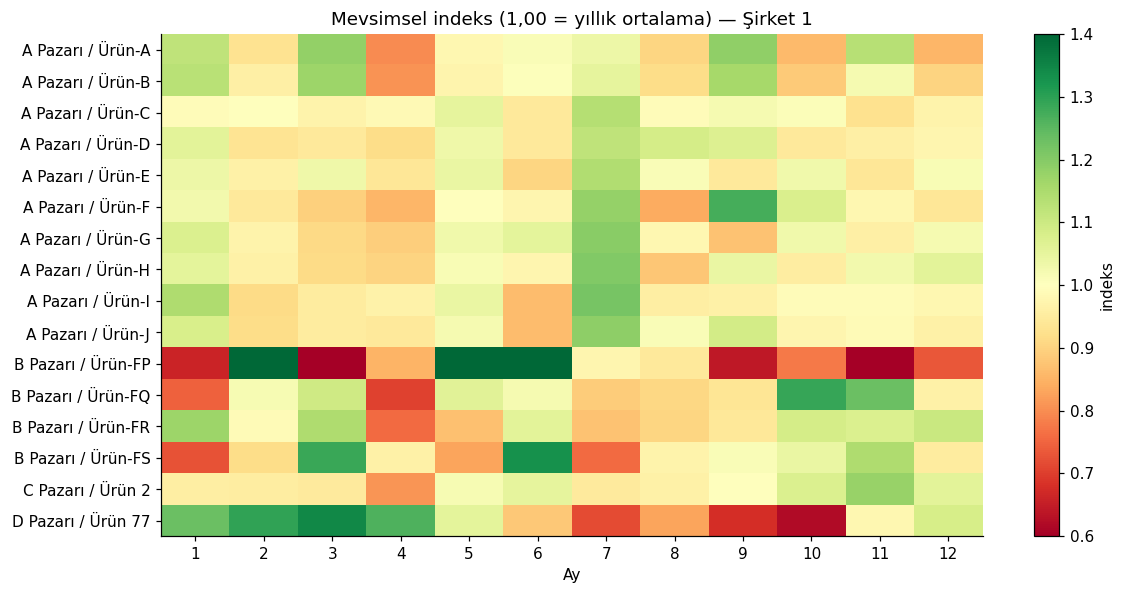

In [16]:
# Isı haritası: ürün × ay mevsimsel indeksi (yalnız hesaplanabilen seriler).
hesaplanabilir = [
    (
        (pazar, urun),
        mevsimsel_indeks(g.sort_values("tarih").set_index("tarih").brut_kutu.astype(float)),
    )
    for (pazar, urun), g in s1.groupby(["pazar", "urun"], observed=True)
]
hesaplanabilir = [(k, v) for k, v in hesaplanabilir if v is not None]

isi = pd.DataFrame({f"{k[0]} / {k[1]}": v for k, v in hesaplanabilir}).T

fig, eksen = plt.subplots(figsize=(11, 5.5))
goruntu = eksen.imshow(isi.to_numpy(), aspect="auto", cmap="RdYlGn", vmin=0.6, vmax=1.4)
eksen.set_xticks(range(12), [str(a) for a in isi.columns])
eksen.set_yticks(range(len(isi)), list(isi.index))
eksen.set_xlabel("Ay")
eksen.set_title("Mevsimsel indeks (1,00 = yıllık ortalama) — Şirket 1")
fig.colorbar(goruntu, ax=eksen, label="indeks")
eksen.grid(False)
fig.tight_layout()
kaydet(fig, "a3_mevsimsellik_isi_haritasi")
plt.show()

#### Teknik yorum

**Şirket 1'in hiçbir ürününde güçlü mevsimsellik yok.** Hesaplanabilen 16 serinin
15'inde mevsimsellik gücü 0,50'nin altında; en yükseği A Pazarı/Ürün-A'da 0,48.
Hyndman ölçeğinde 0,64 üzeri "belirgin mevsimsel" sayılır — bu eşiği aşan tek seri
B Pazarı/Ürün-FP (0,997) ve o da güvenilir değil: yalnız 27 aylık geçmişi var, yani
STL'e 2,25 döngü veriliyor. Bu durum tabloda "sınırda" olarak işaretlendi.

Yine de sistematik bir örüntü var: **A Pazarı'nın on ürününden yedisinde zirve ay
Temmuz**, ikisinde Eylül. Yani A Pazarı'nda ürün bazında değil **pazar seviyesinde**
bir yaz zirvesi var ve tek tek ürünlerde zayıf görünmesinin sebebi gürültü.

🚨 **Veri gerçeğinin sınırı:** case "aynı ürünün farklı pazarlardaki örüntüsü"nü
soruyor ama Şirket 1'in ürün setleri pazarlar arası **ayrık** — A'da Ürün-A…J,
B'de FP…FS, C'de Ürün 1–2, D'de 77–78. Hiçbir ürün birden fazla pazarda yok.
Dolayısıyla bu karşılaştırma ürün seviyesinde **yapılamıyor**; analiz pazar
seviyesinde toplulaştırılmış karşılaştırmaya dönüşüyor. Bu bir eksiklik değil,
verinin yapısı.

#### İş yorumu

Mevsimsellik zayıf olduğu için **stok planlaması mevsime göre değil, promosyon
takvimine göre yapılmalı** — A4'ün gösterdiği gibi asıl dalgalanmayı MF yaratıyor,
mevsim değil. A Pazarı'ndaki Temmuz zirvesi tek eyleme dönüştürülebilir bulgu:
üretim ve kanal doldurma Mayıs–Haziran'da planlanmalı.

`C/Ürün 1` ve `D/Ürün 78` için mevsimsel hedef koymak veriye dayanmaz; bu iki ürün
için hedefler ancak birkaç yıl daha veri biriktikten sonra anlamlı olur.

---
## A4 — Mal fazlasının (MF) bir sonraki ay satışına etkisi

**Olay çalışması.** Olay = `MF Oran > %10` olan (seri, ay) çiftleri. Sonuç ölçüsü
bir sonraki ayın değişimi: `Δ = brut_kutu[t+1] / brut_kutu[t] − 1`. Kontrol grubu
aynı serilerin `MF ≤ %10` olan ayları.

İki test birlikte: **Mann-Whitney U** (dağılım varsayımı yok — Δ dağılımı çarpık) ve
**Welch t-testi** (eşit varyans varsaymıyor). Etki büyüklüğü **Cliff's delta**.
Dört pazar aynı anda test edildiği için p-değerleri **Benjamini-Hochberg FDR** ile
düzeltiliyor.

In [17]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

olay = s1.sort_values(["pazar", "urun", "tarih"]).copy()
olay["sonraki"] = olay.groupby(["pazar", "urun"], observed=True).brut_kutu.shift(-1)
olay["delta"] = np.where(olay.brut_kutu > 0, olay.sonraki / olay.brut_kutu - 1, np.nan)
olay["yuksek_mf"] = olay.mf_oran_temiz > 0.10
olay = olay.dropna(subset=["delta"])

print(
    f"Toplam gözlem: {len(olay)}  |  "
    f"olay: {int(olay.yuksek_mf.sum())}  |  "
    f"kontrol: {int((~olay.yuksek_mf).sum())}"
)

Toplam gözlem: 1783  |  olay: 89  |  kontrol: 1694


In [18]:
def _cliff_delta(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sign(a[:, None] - b[None, :]).sum() / (len(a) * len(b)))


MIN_OLAY = 5
satirlar = []
for pazar, g in olay.groupby("pazar", observed=True):
    o = g[g.yuksek_mf].delta.to_numpy()
    k = g[~g.yuksek_mf].delta.to_numpy()
    satir = {"Pazar": pazar, "Olay n": len(o), "Kontrol n": len(k)}
    if len(o) < MIN_OLAY or len(k) < MIN_OLAY:
        satir["Sonuç"] = "test edilemedi (yetersiz olay)"
        satirlar.append(satir)
        continue
    _, p_mwu = stats.mannwhitneyu(o, k, alternative="two-sided")
    _, p_welch = stats.ttest_ind(o, k, equal_var=False)
    satir.update(
        {
            "Olay medyan Δ": round(float(np.median(o)), 3),
            "Kontrol medyan Δ": round(float(np.median(k)), 3),
            "Mann-Whitney p": p_mwu,
            "Welch p": p_welch,
            "Cliff δ": round(_cliff_delta(o, k), 3),
        }
    )
    satirlar.append(satir)

mf_testi = pd.DataFrame(satirlar)
gecerli = (
    mf_testi["Mann-Whitney p"].notna()
    if "Mann-Whitney p" in mf_testi
    else pd.Series(False, index=mf_testi.index)
)
if gecerli.any():
    mf_testi.loc[gecerli, "FDR q"] = multipletests(
        mf_testi.loc[gecerli, "Mann-Whitney p"], method="fdr_bh"
    )[1]
    mf_testi["Anlamlı (q<0,05)"] = np.where(
        mf_testi["FDR q"].notna(), mf_testi["FDR q"] < 0.05, None
    )
mf_testi

,Pazar,Olay n,Kontrol n,Olay medyan Δ,Kontrol medyan Δ,Mann-Whitney p,Welch p,Cliff δ,Sonuç,FDR q,"Anlamlı (q<0,05)"
0,A Pazarı,71,1159,-0.217,0.010,3.068583e-12,0.000514,-0.493,NaN,9.205748e-12,True
1,B Pazarı,12,379,-0.187,0.007,7.704658e-02,0.050216,-0.300,NaN,1.155699e-01,False
2,C Pazarı,0,101,NaN,NaN,NaN,NaN,NaN,test edilemedi (yetersiz olay),NaN,None
3,D Pazarı,6,55,-0.205,-0.055,8.041863e-01,0.343209,0.067,NaN,8.041863e-01,False


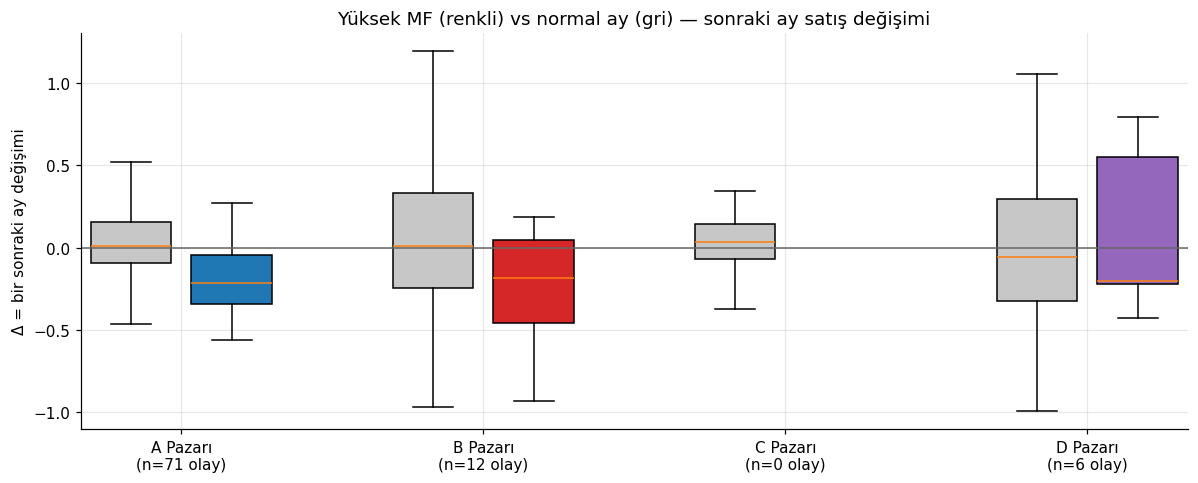

In [19]:
fig, eksen = plt.subplots(figsize=(11, 4.5))
konumlar, etiketler = [], []
for i, pazar in enumerate(PAZARLAR):
    g = olay[olay.pazar == pazar]
    o = g[g.yuksek_mf].delta.to_numpy()
    k = g[~g.yuksek_mf].delta.to_numpy()
    if len(k):
        eksen.boxplot(
            [k],
            positions=[i * 3],
            widths=0.8,
            showfliers=False,
            patch_artist=True,
            boxprops=dict(facecolor="#c7c7c7"),
        )
    if len(o):
        eksen.boxplot(
            [o],
            positions=[i * 3 + 1],
            widths=0.8,
            showfliers=False,
            patch_artist=True,
            boxprops=dict(facecolor=PAZAR_RENKLERI[pazar]),
        )
    konumlar.append(i * 3 + 0.5)
    etiketler.append(f"{pazar}\n(n={len(o)} olay)")
eksen.set_xticks(konumlar, etiketler)
eksen.axhline(0, color="#666666", linewidth=1)
eksen.set_ylabel("Δ = bir sonraki ay değişimi")
eksen.set_title("Yüksek MF (renkli) vs normal ay (gri) — sonraki ay satış değişimi")
fig.tight_layout()
kaydet(fig, "a4_mf_etkisi")
plt.show()

#### Teknik yorum

**A Pazarı'nda etki net ve istatistiksel olarak anlamlı, ama işaret beklenenin
tersi.** 71 olay karşısında 1.159 kontrol ayı: yüksek MF ayını izleyen ayda medyan
değişim **−%21,7**, normal ayları izleyen ayda ise +%1,0. Mann-Whitney
p ≈ 3×10⁻¹², FDR düzeltmesinden sonra q ≈ 9×10⁻¹². Cliff's δ = −0,49, yani
orta-büyük bir etki. İki test de (dağılım varsayımsız ve parametrik) aynı yöne
işaret ediyor.

Diğer üç pazarda **anlamlı sonuç yok**: B Pazarı'nda 12 olayla q ≈ 0,12,
D Pazarı'nda 6 olayla q ≈ 0,80. C Pazarı'nda Şirket 1 hiçbir ayda %10 üzeri MF
kullanmamış, dolayısıyla test edilecek olay yok — bu satır "test edilemedi" olarak
raporlanıyor, sıfır etki olarak değil.

⚠️ Ortalama yerine **medyan** raporlanıyor: D Pazarı'nda ortalama Δ 7,6 çıkıyor ama
bu, paydası çok küçük birkaç aydan kaynaklanan bir artefakt. Küçük hacimli serilerde
oransal değişim patlıyor.

⚠️ Bu bir **korelasyon** bulgusudur, nedensellik değil. Yüksek MF'in kendisi satışı
düşürüyor olabileceği gibi, satışın zaten düşeceği aylarda MF artırılıyor da olabilir.
Case "istatistiksel olarak anlamlı" diyor, "nedensel etki" demiyor.

#### İş yorumu

A Pazarı'ndaki bulgu klasik **kanal doldurma (pull-forward)** örüntüsü: yüksek mal
fazlası verildiği ay kanal doluyor, ertesi ay sipariş düşüyor. Yani MF talep
yaratmıyor, talebi öne çekiyor. Bu, promosyonun maliyetini (A6'daki TL kaybı) ek bir
hacim getirisiyle karşılamadığı anlamına gelir.

Aksiyon: A Pazarı'nda yüksek MF kampanyaları **iki aylık pencerede** değerlendirilmeli;
tek ayın satış rakamına bakarak "kampanya işe yaradı" demek yanıltıcı. B ve D
pazarlarında olay sayısı karar vermek için yetersiz — burada önce daha fazla veri
toplanmalı.